## 理想反转因子 M = M_high - M_low，核心获利逻辑是「M 值越小，股票未来 1 个月的上涨概率 / 涨幅越高；M 值越大，未来下跌概率 / 跌幅越高」

In [1]:
import pandas as pd
import numpy as np

# 读取 .pkl 文件
df = pd.read_pickle('E:\Study materials\因子投资小组学习\量化学习本地\项目实践\W式切割.pkl数据\daily_adj_close_post_20250731.pkl')

# 打印前 5 行
print(df.head())

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_36980\358872509.py:5: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_pickle('E:\Study materials\因子投资小组学习\量化学习本地\项目实践\W式切割.pkl数据\daily_adj_close_post_20250731.pkl')


order_book_id  000001.SZ  000002.SZ  000003.SZ  000004.SZ  000005.SZ  \
date                                                                   
2001-01-02      469.3583   105.0357    36.8922   156.3505    42.9616   
2001-01-03      465.8099   107.7215    37.8037   156.0692    43.7278   
2001-01-04      462.9066   107.8667    36.7482   151.6623    42.9068   
2001-01-05      458.0679   108.4474    36.2685   147.6774    42.7974   
2001-01-08      451.6162   109.8991    35.2131   143.9737    43.2352   

order_book_id  000006.SZ  000007.SZ  000008.SZ  000009.SZ  000010.SZ  ...  \
date                                                                  ...   
2001-01-02      103.3224    72.2466   126.4888    27.3040    36.2436  ...   
2001-01-03      103.8485    75.2063   125.7588    28.2913    36.9553  ...   
2001-01-04      103.1722    74.0964   125.8343    27.9495    36.7972  ...   
2001-01-05      104.2993    75.7876   120.2462    28.2913    36.5599  ...   
2001-01-08      105.7270    70.97

In [2]:
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
import scipy.stats as stats
import statsmodels.api as sm  # 需提前 pip install statsmodels

# ===================== 1. 基础设置 =====================
pd.set_option('future.no_silent_downcasting', True)

def calculate_performance(return_series, forecast_series=None, annual_freq=12, use_newey_west=True):
    ret = return_series.dropna()
    if len(ret) == 0:
        return {}
        
    n_periods = len(ret)
    
    # 1. 基础收益与风险指标
    annual_return = (1 + ret).prod() ** (annual_freq / n_periods) - 1
    annual_vol = ret.std() * np.sqrt(annual_freq)
    sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan
    
    cum_ret = (1 + ret).cumprod() # cumulative period
    running_max = cum_ret.cummax()
    drawdown = (cum_ret / running_max) - 1
    max_dd = abs(drawdown.min()) 
    
    win_rate = (ret > 0).sum() / n_periods
    avg_ret_permonth = ret.mean()
    std_ret_permonth = ret.std()


    return {
        '年化收益': round(annual_return, 4),
        '年化波动率': round(annual_vol, 4),
        '夏普比率': round(sharpe, 4),
        '最大回撤': round(max_dd, 4),
        '月度胜率': round(win_rate, 4),
        '月均收益': round(avg_ret_permonth, 4),
        '月收益波动率': round(std_ret_permonth, 4)
    }


# plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei']
# plt.rcParams['axes.unicode_minus'] = False

# ===================== 2. 读取与对齐数据 =====================
pkl_dir = 'E:/Study materials/因子投资小组学习/量化学习本地/项目实践/W式切割.pkl数据'
try:
    adj_close = pd.read_pickle(f'{pkl_dir}/daily_adj_close_post_20250731.pkl')
    num_trades = pd.read_pickle(f'{pkl_dir}/daily_num_trades_20251231.pkl')
    total_amount = pd.read_pickle(f'{pkl_dir}/daily_total_amount_20251231.pkl')
    st = pd.read_pickle(f'{pkl_dir}/stock_st_flag_20251231.pkl')
    sus = pd.read_pickle(f'{pkl_dir}/stock_suspend_flag_20251231.pkl')
    ns = pd.read_pickle(f'{pkl_dir}/new_stock_flag_20251231.pkl')
    limit_up = pd.read_pickle(f'{pkl_dir}/daily_limit_up_flag_20251231.pkl')
    limit_down = pd.read_pickle(f'{pkl_dir}/daily_limit_down_flag_20251231.pkl')
    print("✅ 所有文件读取成功！")
except FileNotFoundError as e:
    print(f"❌ 文件未找到：{e}")
    raise

# 统一索引格式
all_data = [adj_close, num_trades, total_amount, st, sus, ns, limit_up, limit_down]
for i, df in enumerate(all_data):
    df.index = pd.to_datetime(df.index)
    # 指示各个表格的索引
    all_data[i] = df

# 取日期的交集 和 股票的交集
common_dates = all_data[0].index
for df in all_data[1:]:
    common_dates = common_dates.intersection(df.index)
    # 我：不断向后取交集

common_stocks = all_data[0].columns
for df in all_data[1:]:
    common_stocks = common_stocks.intersection(df.columns)

print(f"📊 数据对齐后：{len(common_dates)}天，{len(common_stocks)}只股票")

# 强制对齐所有数据
adj_close = adj_close.reindex(index=common_dates, columns=common_stocks)
num_trades = num_trades.reindex(index=common_dates, columns=common_stocks)
total_amount = total_amount.reindex(index=common_dates, columns=common_stocks)
st = st.reindex(index=common_dates, columns=common_stocks)
sus = sus.reindex(index=common_dates, columns=common_stocks)
ns = ns.reindex(index=common_dates, columns=common_stocks)
limit_up = limit_up.reindex(index=common_dates, columns=common_stocks)
limit_down = limit_down.reindex(index=common_dates, columns=common_stocks)

# ===================== 3. 基础指标 =====================
daily_ret = adj_close.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
# percentage change。前一天数据缺失NaN，则这一天的百分比变化也被（默认方法fill_method=None）计算为缺失NaN，
avg_trade_amt = (total_amount / num_trades).replace([np.inf, -np.inf, 0], np.nan)

# 月度过滤mask
#  'ME' 是 Pandas 中的频率字符串（Frequency String），代表 Month End（月末）。
# 在 resample('ME')中，它告诉 Pandas 将数据按“月”进行分组，().last确保取最后一天。
st_month = st.resample('ME').last().fillna(False)
sus_month = sus.resample('ME').last().fillna(False)
ns_month = ns.resample('ME').last().fillna(False)
limit_up_month = limit_up.resample('ME').last().fillna(False)
limit_down_month = limit_down.resample('ME').last().fillna(False)
msk_month = ~sus_month & ~st_month & ~ns_month & ~limit_up_month & ~limit_down_month
# msk_month实质是一个表格df，对应在某个月末某个股票可以交易
# 防止后续 NumPy 数组运算时位置错位
msk_month = msk_month.reindex(columns=common_stocks)
# 这不会影响股票M_high - M_low，但由于某些被踢出的股票月末无法交易，正好对应这了月末做5分组时被排除的股票。

# ===================== 4. 核心修复：使用 NumPy 滑动窗口计算因子 =====================
def calculate_w_cut_factor(amt_matrix, ret_matrix, window=20):
    """
    向量化计算W式切割因子（高效，避免循环）
    amt_matrix: 日均单笔成交金额矩阵 (T, N)，T=天数，N=股票数
    ret_matrix: 日收益率矩阵 (T, N)
    window: 滚动窗口长度（默认20日）
    return: 因子矩阵 (T, N)
    """
    T, N = amt_matrix.shape
    factor_matrix = np.full((T, N), np.nan)

    # 生成滑动窗口视图：(T - window + 1, N, window) # (T-19, N, 20)?
    if T < window:
        return factor_matrix

    amt_windows = sliding_window_view(amt_matrix, window_shape=window, axis=0)  # 初始表，窗口长度，沿行
    ret_windows = sliding_window_view(ret_matrix, window_shape=window, axis=0)  
    # amt_windows 和 ret_windows的形状是 (T-19, N, 20)。分别代表有多少个滑动窗口、有的多少只股票、每个窗口包含多少数据。

    # 检查每个窗口的缺失值
    valid_mask = (~np.isnan(amt_windows)) & (~np.isnan(ret_windows))
    valid_window_mask = valid_mask.sum(axis=2) == window  # 同一个窗口、同一只股票，沿 窗口内 20天都有每日平均的那笔成交金额和收益率
    # 对有效窗口，按成交金额排序，计算 M_high - M_low
    # 1. 获取有效窗口的索引
    t_idx, n_idx = np.where(valid_window_mask)

    # 2. 提取有效窗口的数据
    valid_amt = amt_windows[t_idx, n_idx, :]  # (有效窗口数, 20)
    valid_ret = ret_windows[t_idx, n_idx, :]  # (有效窗口数, 20)

    # 3. 按成交金额排序（得到排序后的索引）
    sorted_indices = np.argsort(valid_amt, axis=1)  # axis=1：选取股票列 里面的数据被提取排序后的索引

    # 4. 根据排序索引提取收益率
    sorted_ret = np.take_along_axis(valid_ret, sorted_indices, axis=1)  # (有效窗口数, 20)

    # 5. 计算 M_high（后10天）和 M_low（前10天）
    M_low = sorted_ret[:, :10].sum(axis=1)
    M_high = sorted_ret[:, 10:].sum(axis=1)
    factor_values = M_high - M_low

    # 6. 将计算结果填回因子矩阵
    factor_matrix[t_idx + window - 1, n_idx] = factor_values  # 窗口最后一天对应因子值

    return factor_matrix

print("🔄 开始向量化计算W式切割因子（预计10-30秒）...")

# 转换为 numpy 矩阵（注意：values 会自动处理索引，按列对齐）
amt_values = avg_trade_amt.values
ret_values = daily_ret.values

# 计算因子矩阵
factor_matrix = calculate_w_cut_factor(amt_values, ret_values, window=20)

# 转换回 DataFrame
factor_df = pd.DataFrame(factor_matrix, index=common_dates, columns=common_stocks)
print("✅ 因子计算完成！")

# ===================== 5. 分组回测 =====================
# 目标：按月末因子选股
# 提取月末因子并过滤
# 由于某些被踢出的股票月末无法交易，正好对应这了月末做5分组时被排除的股票
month_end_factor = factor_df.resample('ME').last()
# 我：提取月末因子，是表格格式df
month_end_factor = month_end_factor.reindex(index=msk_month.index, columns=common_stocks)
month_end_factor_filtered = month_end_factor.where(msk_month, np.nan)
# 某个月末某个股票不可交易，不在msk_month里面，直接排除

# 计算月度持仓收益
monthly_ret = adj_close.resample('ME').last().pct_change(fill_method=None)
# 我：仍然percentile change，adj_close.resample('ME').last()表格存储每一个月最后一天收盘价，monthly_ret则通过本月末和上个月末的收盘价提取月度收益率

# 为用因子对应真实的未来收益做准备
forward_monthly_ret = monthly_ret.shift(-1)
forward_monthly_ret = forward_monthly_ret.reindex(index=month_end_factor.index, columns=common_stocks)
# 对齐month_end_factor行索引

# 分组参数
N_GROUP = 5
group_names = [f'G{i+1}' for i in range(N_GROUP)]
group_monthly_ret = pd.DataFrame(index=month_end_factor.index, columns=group_names, dtype=float)
# CC: 这会让所有分组列（G1~G5）从一开始就是 float64 类型，后续 .loc[date, group] = scalar 赋值时也不会退化成 object，ttest_1samp 就能正常计算。
# 与已有的 long_short_ret = pd.Series(index=month_end_factor.index, dtype=float) 保持一致的风格。
long_short_ret = pd.Series(index=month_end_factor.index, dtype=float) 

# 逐月分组
print("🔄 开始分组回测...")
for date in month_end_factor.index:
    factor_se = month_end_factor_filtered.loc[date].dropna()
    # 上面一个步骤确保这个月末日，后续参与分组的都是这个月末可交易的股票
    if len(factor_se) < N_GROUP:
        continue
    factor_rank = factor_se.rank(method='first')
    # 无论什么method都是从小到大排序。当遇到数值完全相同（并列）的情况时，不同method表现不一样，如first加上数值相同原序列序号小在前面的规则，last相反，mean则两个并列9号则都变为9.5号。
    group_bins = pd.qcut(factor_rank, q=N_GROUP, labels=group_names)
    # 以上两步在给股票分组
    for group in group_names:
        group_stocks = group_bins[group_bins == group].index
        group_monthly_ret.loc[date, group] = forward_monthly_ret.loc[date, group_stocks].mean()
        # 注意是forward_monthly_ret！这个被预测到的组Gi的股票组合下一个月真实收益率的均值，
        # 且这个mean()默认会提取组内“下一个月月度收益率”存在的股票组合的“下一个月月度收益率”做平均，被会因为这个月末没有收盘价值为NaN影响（大概率不会一个组月末都没有收盘价）
        # 何况我认为被筛选出的这个月末可交易的股票，收盘价也不会是NaN
    long_short_ret.loc[date] = group_monthly_ret.loc[date, 'G1'] - group_monthly_ret.loc[date, 'G5']

group_monthly_ret = group_monthly_ret.dropna(how='all')
long_short_ret = long_short_ret.dropna()
# 我觉得这里的.dropna()不合逻辑且没有用，
# 不合逻辑是因为要是真的与月末组和收益为NaN也不应该删除这一项使得月份数据不连续，
# 没有用是因为每个月末各个组股票组合的收益都不会是NaN,多空组合后也不会是！

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_36980\211746058.py:7: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


✅ 所有文件读取成功！
📊 数据对齐后：5957天，5462只股票
🔄 开始向量化计算W式切割因子（预计10-30秒）...
✅ 因子计算完成！
🔄 开始分组回测...



多空组合绩效（W式切割反转因子）
年化收益: 0.1704
年化波动率: 0.0827
夏普比率: 2.0597
最大回撤: 0.0859
月度胜率: 0.7406
月均收益: 0.0135
月收益波动率: 0.0239

5分组年化收益对比
G1组 年化收益: 0.1741
G2组 年化收益: 0.1364
G3组 年化收益: 0.1054
G4组 年化收益: 0.0761
G5组 年化收益: -0.0092


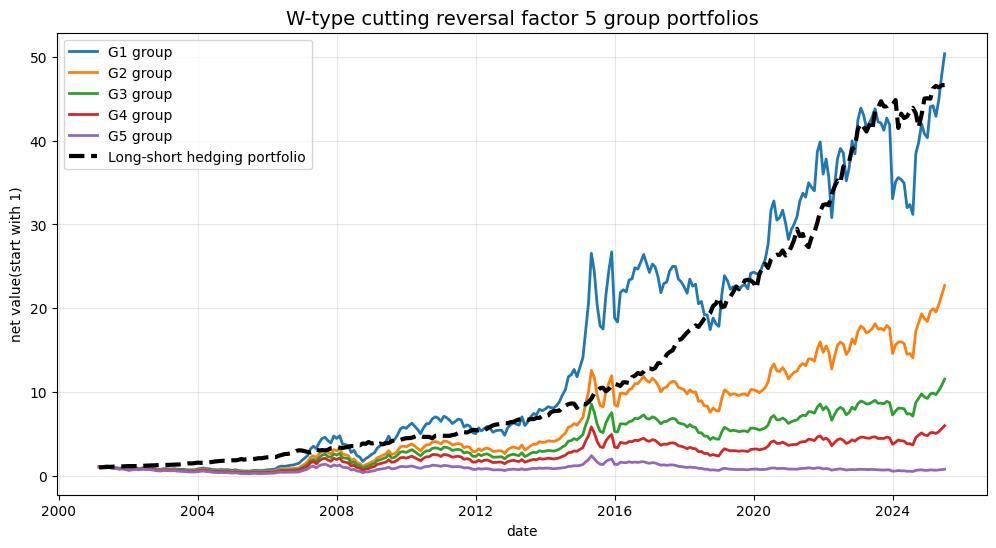

In [3]:
# ===================== 6. 绩效分析与可视化 =====================
print("\n" + "="*50)
print("多空组合绩效（W式切割反转因子）")
print("="*50)
ls_perf = calculate_performance(long_short_ret)
for key, value in ls_perf.items():
    print(f"{key}: {value}")
# 这一步把所有之前预计想获得因子指标输出

print("\n" + "="*50)
print("5分组年化收益对比")
print("="*50)
for group in group_names:
    group_perf = calculate_performance(group_monthly_ret[group])
    print(f"{group}组 年化收益: {group_perf.get('年化收益', np.nan)}")

plt.figure(figsize=(12, 6))
group_net_value = (1 + group_monthly_ret).cumprod()
# 图上画的是如果一直做多某个组Gi按月叠加的累计收益，
for group in group_names:
    plt.plot(group_net_value.index, group_net_value[group], label=f'{group} group', linewidth=2)
ls_net_value = (1 + long_short_ret).cumprod()
plt.plot(ls_net_value.index, ls_net_value, label='Long-short hedging portfolio', linewidth=3, color='black', linestyle='--')
plt.title('W-type cutting reversal factor 5 group portfolios', fontsize=14)
plt.xlabel('date')
plt.ylabel('net value(start with 1)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
# ===================== 7. 因子有效性检验：Rank IC 分析 =====================
# 逐月末截面：因子值 vs 下月收益 → Spearman Rank IC → IC 时间序列
print("\n" + "="*50)
print("因子有效性检验 — Rank IC 分析（W式切割反转因子）")
print("="*50)

MIN_STOCKS = 30  # 截面有效股票数不足的月份不计入

ic_series = pd.Series(index=month_end_factor.index, dtype=float)

for date in month_end_factor.index:
    factor_se = month_end_factor_filtered.loc[date]
    ret_se = forward_monthly_ret.loc[date]

    valid_mask = factor_se.notna() & ret_se.notna()
    if valid_mask.sum() < MIN_STOCKS:
        continue

    f_valid = factor_se[valid_mask]
    r_valid = ret_se[valid_mask]

    ic, _ = stats.spearmanr(f_valid, r_valid)
    ic_series.loc[date] = ic

ic_series = ic_series.dropna()

# --- 统计量 ---
ic_mean = ic_series.mean()
ic_std = ic_series.std()
icir = ic_mean / ic_std if ic_std != 0 else np.nan
n = len(ic_series)

# Newey-West 调整的 T 统计量（maxlags 按 Newey & West 经验法则）
t_plain = ic_mean / (ic_std / np.sqrt(n)) if ic_std != 0 else np.nan

if n > 2:
    X_const = np.ones(n)
    model = sm.OLS(ic_series.values, X_const)
    nw_lags = max(1, int(4 * (n / 100) ** (2 / 9)))  # Newey & West 经验法则
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    t_nw = results.tvalues[0]
else:
    t_nw = np.nan

print(f"有效月份数: {n}")
print(f"IC 均值: {ic_mean:.4f}")
print(f"IC 标准差: {ic_std:.4f}")
print(f"ICIR: {icir:.4f}")
print(f"T 统计量（普通）: {t_plain:.4f}")
print(f"T 统计量（Newey-West）: {t_nw:.4f}")


因子有效性检验 — Rank IC 分析（W式切割反转因子）
有效月份数: 293
IC 均值: -0.0644
IC 标准差: 0.0838
ICIR: -0.7677
T 统计量（普通）: -13.1410
T 统计量（Newey-West）: -13.9914
